## Visualize Structural and Functional Connectivity Matrices

This notebook loads the structural and functional connectivity matrices from the `matrixdata` folder and visualizes them as heatmaps, similar to the plots in `figure_2.py`.

/Users/quanwen/Documents/GitHub/SC-FC/venv/lib/python3.11/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)


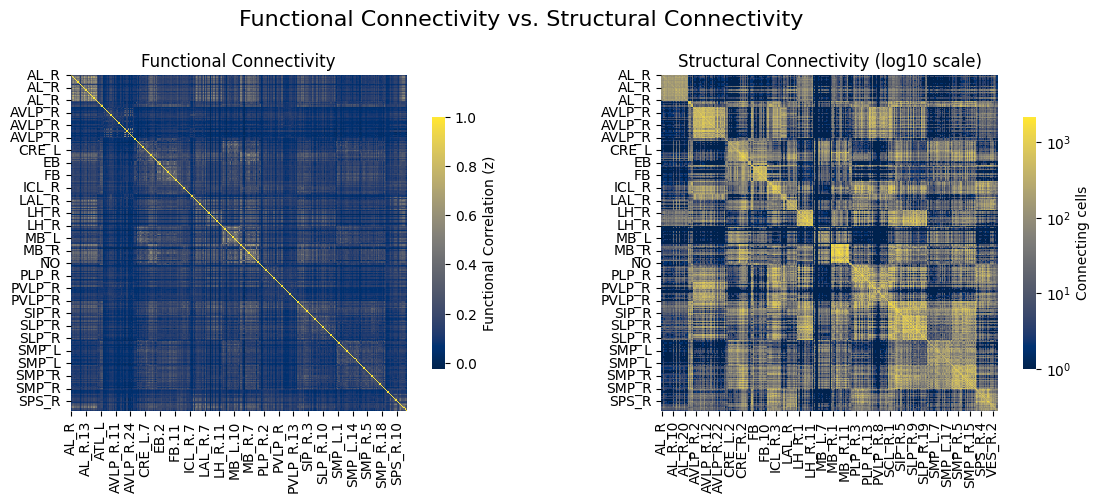

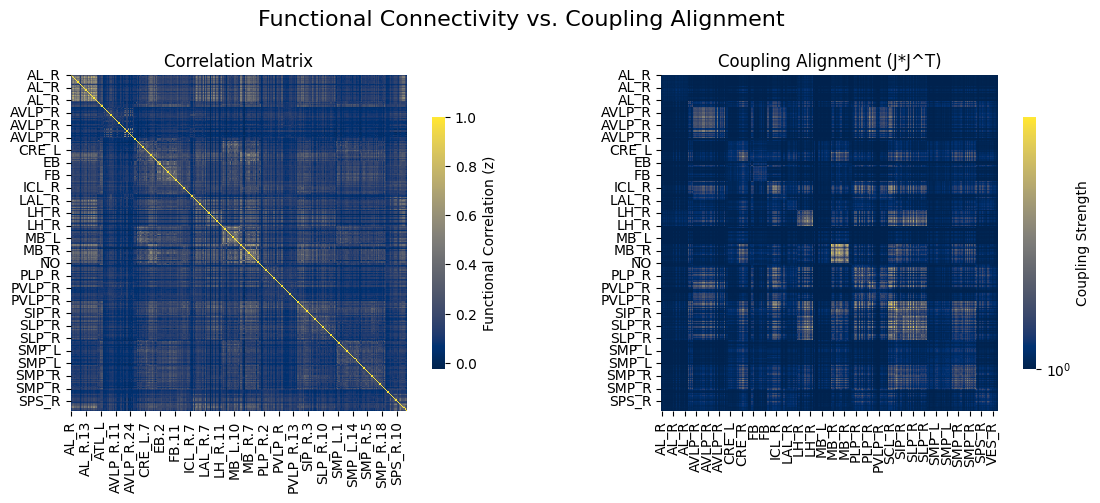

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import os

# This script assumes you have the scfc package installed and the data in the correct location.
# If you are running this from the root of the repository, the paths should be correct.
from scfc import bridge, subsampling, anatomical_connectivity

# --- 1. Load the data ---
data_dir = bridge.getUserConfiguration()['data_dir']

# Load Functional Connectivity Matrix
functional_matrix_path = os.path.join(data_dir, 'CorrelationMatrix_branson.csv')
Functional_Matrix = pd.read_csv(functional_matrix_path, index_col=0)
vals = Functional_Matrix.to_numpy()
np.fill_diagonal(vals, 1)
Functional_Matrix.loc[:,:] = vals

# Load Structural Connectivity Matrix (J)
structural_matrix_path = os.path.join(data_dir, 'StructuralMatrix_branson.csv')
Structural_Matrix = pd.read_csv(structural_matrix_path, index_col=0)
vals = Structural_Matrix.to_numpy()
np.fill_diagonal(vals, 0)
Structural_Matrix.loc[:, :] = vals

# --- 2. Plot Functional vs Structural ---
fig1, ax1 = plt.subplots(1, 2, figsize=(12, 5))
fig1.suptitle('Functional Connectivity vs. Structural Connectivity', fontsize=16)

# Functional heatmap
sns.heatmap(Functional_Matrix, ax=ax1[0],
            #yticklabels=False,
            #xticklabels=False,
            cbar_kws={'label': 'Functional Correlation (z)', 'shrink': .75}, cmap="cividis", rasterized=True)
ax1[0].set_title('Functional Connectivity')
ax1[0].set_aspect('equal')

# Structural heatmap
J_for_plotting = Structural_Matrix
#np.fill_diagonal(J_for_plotting.values, np.nan) # Replace diagonal with NaN for plotting
sns.heatmap(np.log10(J_for_plotting).replace([np.inf, -np.inf], 0), ax=ax1[1],
            #yticklabels=False,
            #xticklabels=False,
            cmap="cividis", rasterized=True, cbar=False)
cb1 = fig1.colorbar(matplotlib.cm.ScalarMappable(norm=matplotlib.colors.SymLogNorm(vmin=1, vmax=np.nanmax(J_for_plotting.to_numpy()), base=10, linthresh=0.1, linscale=1), cmap="cividis"), ax=ax1[1], shrink=0.75, label='Connecting cells')
cb1.outline.set_linewidth(0)
ax1[1].set_title('Structural Connectivity (log10 scale)')
ax1[1].set_aspect('equal')

fig1.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- 3. Calculate Coupling Alignment Matrix (J * J^T) ---
J = Structural_Matrix
N = J.shape[0]
# Fill diagonal with 0 before matrix multiplication
#np.fill_diagonal(J.values, 0)
Coupling_Alignment = (J @ J.T)
#Coupling_Alignment_values = J.to_numpy() + J.to_numpy().T
#Coupling_Alignment = pd.DataFrame(Coupling_Alignment_values, index=J.index, columns=J.columns)
Coupling_Alignment = Coupling_Alignment / np.trace(Coupling_Alignment) * N

# Perform addition on the underlying numpy arrays to ignore labels
Structure_values = J.to_numpy() + J.to_numpy().T

# If you want to put it back into a DataFrame with the original labels:



# --- 4. Plot Functional vs Coupling Alignment ---
fig2, ax2 = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle('Functional Connectivity vs. Coupling Alignment', fontsize=16)

# Functional heatmap
sns.heatmap(Functional_Matrix, ax=ax2[0],
            #yticklabels=False,
            #xticklabels=False,
            cbar_kws={'label': 'Functional Correlation (z)', 'shrink': .75}, cmap="cividis", rasterized=True)
ax2[0].set_title('Correlation Matrix')
ax2[0].set_aspect('equal')

# Coupling Alignment heatmap
sns.heatmap(Coupling_Alignment, ax=ax2[1],
            #yticklabels=False,
            #xticklabels=False,
            cmap="cividis", rasterized=True, cbar=False)
cb2 = fig2.colorbar(matplotlib.cm.ScalarMappable(norm=matplotlib.colors.SymLogNorm(vmin=1, vmax=np.nanmax(Coupling_Alignment.to_numpy()), base=10, linthresh=0.1, linscale=1), cmap="cividis"), ax=ax2[1], shrink=0.75, label='Coupling Strength')
cb2.outline.set_linewidth(0)
ax2[1].set_title('Coupling Alignment (J*J^T)')
ax2[1].set_aspect('equal')

fig2.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


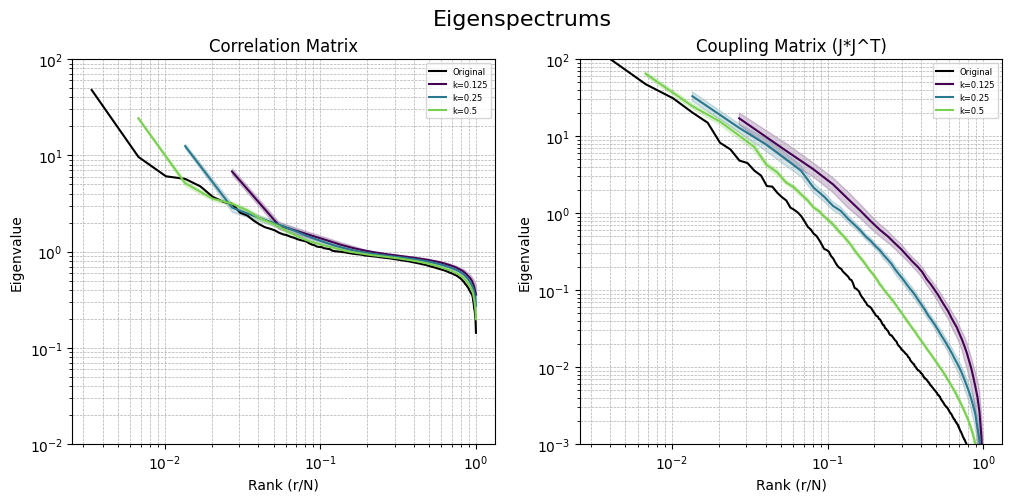

In [3]:
evals = np.linalg.eigvalsh(Functional_Matrix)
evals = np.sort(evals)[::-1]

k_fractions = [0.125, 0.25, 0.5]
n_iter = 50

fig3, ax3 = plt.subplots(1, 2, figsize=(12, 5))
fig3.suptitle('Eigenspectrums', fontsize=16)

ranks_orig = (np.arange(len(evals)) + 1) / len(evals)
ax3[0].loglog(ranks_orig, evals, 'k-', linewidth=1.5, alpha=1.0, label='Original')

colors = plt.cm.viridis(np.linspace(0, 0.8, len(k_fractions)))

for i, k_fraction in enumerate(k_fractions):
    mean_evals, std_evals, _ = subsampling.get_subsampled_eigenspectrum(Functional_Matrix.to_numpy(), k_fraction, n_iter)
    ranks_sub = (np.arange(len(mean_evals)) + 1) / len(mean_evals)
    ax3[0].loglog(ranks_sub, mean_evals, color=colors[i], linewidth=1.5, label='k={}'.format(k_fraction))
    ax3[0].fill_between(ranks_sub, mean_evals - std_evals, mean_evals + std_evals, color=colors[i], alpha=0.2)


ax3[0].set_xlabel('Rank (r/N)')
ax3[0].set_ylabel('Eigenvalue')
ax3[0].set_ylim([10**-2, 10**2])
ax3[0].legend(fontsize=6)
ax3[0].set_title('Correlation Matrix')
ax3[0].grid(True, which='both', linestyle='--', linewidth=0.5)



evals = np.linalg.eigvalsh(Coupling_Alignment)
evals = np.sort(evals)[::-1]

ranks_orig = (np.arange(len(evals)) + 1) / len(evals)
ax3[1].loglog(ranks_orig, evals, 'k-', linewidth=1.5, alpha=1.0, label='Original')

colors = plt.cm.viridis(np.linspace(0, 0.8, len(k_fractions)))

for i, k_fraction in enumerate(k_fractions):
    mean_evals, std_evals, _ = subsampling.get_subsampled_eigenspectrum(Coupling_Alignment.to_numpy(), k_fraction, n_iter)
    ranks_sub = (np.arange(len(mean_evals)) + 1) / len(mean_evals)
    ax3[1].loglog(ranks_sub, mean_evals, color=colors[i], linewidth=1.5, label='k={}'.format(k_fraction))
    ax3[1].fill_between(ranks_sub, mean_evals - std_evals, mean_evals + std_evals, color=colors[i], alpha=0.2)


ax3[1].set_xlabel('Rank (r/N)')
ax3[1].set_ylabel('Eigenvalue')
ax3[1].set_ylim([10**-3, 10**2])
ax3[1].legend(fontsize=6)
ax3[1].set_title('Coupling Matrix (J*J^T)')
ax3[1].grid(True, which='both', linestyle='--', linewidth=0.5)



plt.show()

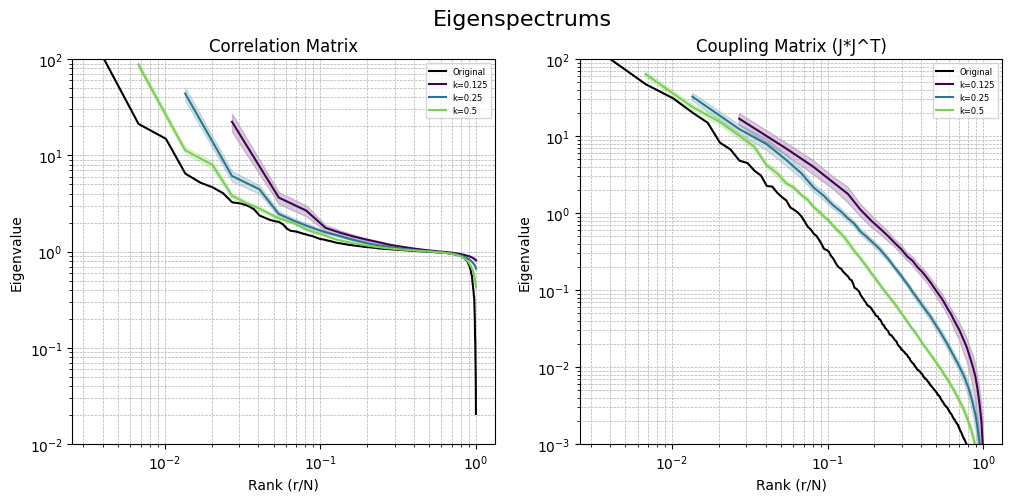

In [4]:
g = 0.6
W = subsampling.generate_W_matrix(Coupling_Alignment.to_numpy(),g)
#W = J.to_numpy() / (120.0 * N)
Correlation_Matrix = subsampling.compute_functional_connectivity(W)

evals = np.linalg.eigvalsh(Correlation_Matrix)
evals = np.sort(evals)[::-1]

k_fractions = [0.125, 0.25, 0.5]
n_iter = 50

fig4, ax4 = plt.subplots(1, 2, figsize=(12, 5))
fig4.suptitle('Eigenspectrums', fontsize=16)

ranks_orig = (np.arange(len(evals)) + 1) / len(evals)
ax4[0].loglog(ranks_orig, evals, 'k-', linewidth=1.5, alpha=1.0, label='Original')

colors = plt.cm.viridis(np.linspace(0, 0.8, len(k_fractions)))

for i, k_fraction in enumerate(k_fractions):
    mean_evals, std_evals, _ = subsampling.get_subsampled_eigenspectrum(Correlation_Matrix, k_fraction, n_iter)
    ranks_sub = (np.arange(len(mean_evals)) + 1) / len(mean_evals)
    ax4[0].loglog(ranks_sub, mean_evals, color=colors[i], linewidth=1.5, label='k={}'.format(k_fraction))
    ax4[0].fill_between(ranks_sub, mean_evals - std_evals, mean_evals + std_evals, color=colors[i], alpha=0.2)


ax4[0].set_xlabel('Rank (r/N)')
ax4[0].set_ylabel('Eigenvalue')
ax4[0].set_ylim([10**-2, 10**2])
ax4[0].legend(fontsize=6)
ax4[0].set_title('Correlation Matrix')
ax4[0].grid(True, which='both', linestyle='--', linewidth=0.5)


evals = np.linalg.eigvalsh(Coupling_Alignment)
evals = np.sort(evals)[::-1]

ranks_orig = (np.arange(len(evals)) + 1) / len(evals)
ax4[1].loglog(ranks_orig, evals, 'k-', linewidth=1.5, alpha=1.0, label='Original')

colors = plt.cm.viridis(np.linspace(0, 0.8, len(k_fractions)))

for i, k_fraction in enumerate(k_fractions):
    mean_evals, std_evals, _ = subsampling.get_subsampled_eigenspectrum(Coupling_Alignment.to_numpy(), k_fraction, n_iter)
    ranks_sub = (np.arange(len(mean_evals)) + 1) / len(mean_evals)
    ax4[1].loglog(ranks_sub, mean_evals, color=colors[i], linewidth=1.5, label='k={}'.format(k_fraction))
    ax4[1].fill_between(ranks_sub, mean_evals - std_evals, mean_evals + std_evals, color=colors[i], alpha=0.2)


ax4[1].set_xlabel('Rank (r/N)')
ax4[1].set_ylabel('Eigenvalue')
ax4[1].set_ylim([10**-3, 10**2])
ax4[1].legend(fontsize=6)
ax4[1].set_title('Coupling Matrix (J*J^T)')
ax4[1].grid(True, which='both', linestyle='--', linewidth=0.5)

fig3.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()


from neuprint import Client

# start client
token = bridge.getUserConfiguration()['token']
neuprint_client = Client('neuprint.janelia.org', dataset='hemibrain:v1.2.1', token=token)
#region_matrix, region_ids = anatomical_connectivity.fetchRegionConnectivity(neuprint_client)
Synaptic_matrix, cell_ids, region_labels = anatomical_connectivity.fetchSynapticMatrix(neuprint_client)

import scipy.sparse

save_dir = os.path.join(data_dir, 'connectome_connectivity')
os.makedirs(save_dir, exist_ok=True)

scipy.sparse.save_npz(os.path.join(save_dir, 'Synaptic_matrix.npz'),Synaptic_matrix)
np.save(os.path.join(save_dir, 'cell_ids.npy'), cell_ids)
np.save(os.path.join(save_dir, 'region_labels.npy'), region_labels)

print(f'Saved to {save_dir}')


In [24]:
import scipy.sparse

save_dir = os.path.join(data_dir, 'connectome_connectivity')

Synaptic_matrix = scipy.sparse.load_npz(os.path.join(save_dir, 'Synaptic_matrix.npz'))
cell_ids = np.load(os.path.join(save_dir, 'cell_ids.npy'), allow_pickle=True)
region_labels = np.load(os.path.join(save_dir, 'region_labels.npy'), allow_pickle=True)

print(f'Loaded from {save_dir}')
print(f'Synaptic_matrix shape:{Synaptic_matrix.shape}')                
print(f'Number of neurons:{len(cell_ids)}')                    
print(f'Number of regions:{len(np.unique(region_labels))}')
print(f'Non-zero entries:{Synaptic_matrix.nnz}')
print(f'Sparsity: {1 - Synaptic_matrix.nnz / (Synaptic_matrix.shape[0] ** 2):.4f}')

Loaded from /Users/quanwen/Documents/fly-center-brain/data/connectome_connectivity
Synaptic_matrix shape:(21108, 21108)
Number of neurons:21108
Number of regions:33
Non-zero entries:3497717
Sparsity: 0.9921


In [26]:
rng = np.random.default_rng(seed=42)
fraction = 0.1  # keep 25% of neurons per region

keep = np.zeros(len(cell_ids), dtype=bool)
for roi in np.unique(region_labels):
    inds = np.where(region_labels == roi)[0]
    k = max(1, int(len(inds) * fraction))
    chosen = rng.choice(inds, k, replace=False)
    keep[chosen] = True

Synaptic_matrix_sub = Synaptic_matrix[keep][:, keep]
cell_ids_sub = cell_ids[keep]
region_labels_sub = region_labels[keep]

print(f'Original: {Synaptic_matrix.shape[0]} neurons')
print(f'Subsampled: {Synaptic_matrix_sub.shape[0]} neurons ({fraction*100:.0f}% per region)')
print(f'Non-zero entries: {Synaptic_matrix_sub.nnz}')


Original: 21108 neurons
Subsampled: 2097 neurons (10% per region)
Non-zero entries: 34260


Removed 30 neurons with zero diagonal, 2067 remaining


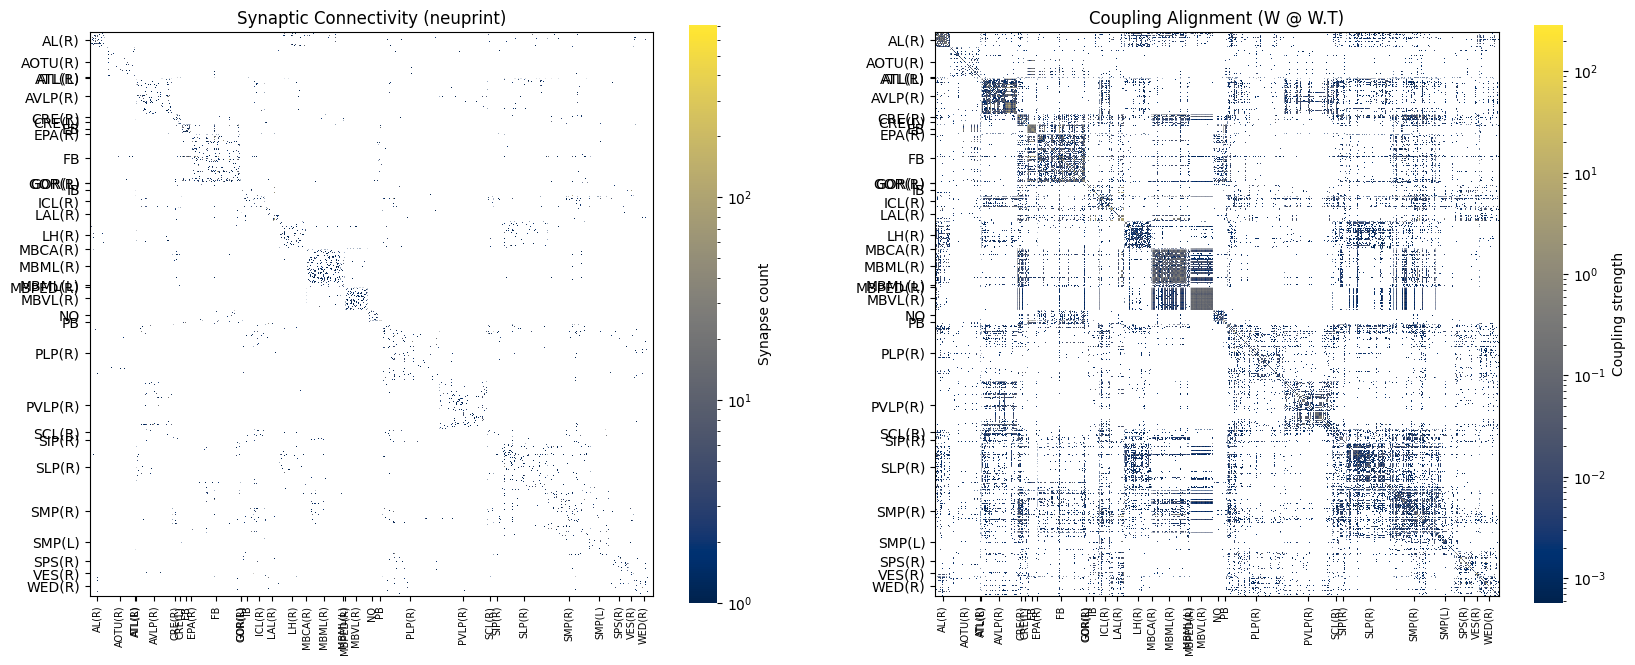

In [27]:
import matplotlib.colors as colors

# Convert sparse matrix to dense
W = Synaptic_matrix_sub.toarray().astype(float)
W_masked = np.ma.masked_where(W <= 0, W)
np.fill_diagonal(W, 0)

# Compute region boundary positions from region_labels
unique_regions, region_starts = np.unique(region_labels_sub, return_index=True)
# sort by first occurrence to preserve ordering
order = np.argsort(region_starts)
unique_regions = unique_regions[order]
region_starts = region_starts[order]
boundaries = np.append(region_starts, len(region_labels_sub))

fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# --- Synaptic connectivity ---
im0 = ax[0].imshow(
    W_masked,
    cmap='cividis',
    norm=colors.LogNorm(vmin=W_masked.min(), vmax=W_masked.max()),
    aspect='equal',
    interpolation='nearest',
    rasterized=True,
)
ax[0].set_facecolor('white')
ax[0].set_title('Synaptic Connectivity (neuprint)')
cb0 = fig.colorbar(im0, ax=ax[0], shrink=0.75, label='Synapse count')
cb0.outline.set_linewidth(0)


# Region boundary lines + labels
for i, (roi, start) in enumerate(zip(unique_regions, region_starts)):
    ax[0].axhline(start - 0.5, color='white', linewidth=1, alpha=0.6)
    ax[0].axvline(start - 0.5, color='white', linewidth=1, alpha=0.6)


b = boundaries.ravel()                        
mids = [float(b[i] + b[i+1]) / 2 for i in range(len(unique_regions))]

#import traceback                              
#try:
ax[0].set_xticks(mids)                      
ax[0].set_xticklabels(unique_regions,rotation=90,fontsize=7)                      
ax[0].set_yticks(mids)
ax[0].set_yticklabels(unique_regions,fontsize=10)
#except Exception as e:
#    traceback.print_exc()
    

# --- Coupling alignment W @ W.T ---
Coupling = W @ W.T
N = W.shape[0]
Coupling = Coupling / np.trace(Coupling) * N
Coupling_masked = np.ma.masked_where(Coupling <= 0, Coupling)

d = np.sqrt(np.diag(Coupling))
keep = d > 0                            
   
Coupling = Coupling[np.ix_(keep, keep)] 
W = W[keep][:, keep]
region_labels_sub = region_labels_sub[keep]
cell_ids_sub = cell_ids_sub[keep]

#d = d[keep]
#Coupling = Coupling / np.outer(d, d)
#np.fill_diagonal(Coupling, 1.0)

print(f'Removed {(~keep).sum()} neurons with zero diagonal, {keep.sum()} remaining')


im1 = ax[1].imshow(
    Coupling_masked,
    cmap='cividis',
    norm=colors.LogNorm(vmin=np.nanmin(Coupling_masked), vmax=np.nanmax(Coupling_masked)),
    aspect='equal',
    interpolation='nearest',
    rasterized=True,
)
ax[1].set_facecolor('white')
ax[1].set_title('Coupling Alignment (W @ W.T)')
cb1 = fig.colorbar(im1, ax=ax[1], shrink=0.75, label='Coupling strength')
cb1.outline.set_linewidth(0)

for i, (roi, start) in enumerate(zip(unique_regions, region_starts)):
    ax[1].axhline(start - 0.5, color='white', linewidth=0.5, alpha=0.6)
    ax[1].axvline(start - 0.5, color='white', linewidth=0.5, alpha=0.6)

ax[1].set_xticks(mids)                      
ax[1].set_xticklabels(unique_regions,rotation=90,fontsize=7)                      
ax[1].set_yticks(mids)
ax[1].set_yticklabels(unique_regions,fontsize=10)

plt.show()

Diagonal range:[0,52.74]
Removing 511 / 1205 nodes with diagonal < 0.1
Remaining nodes: 694


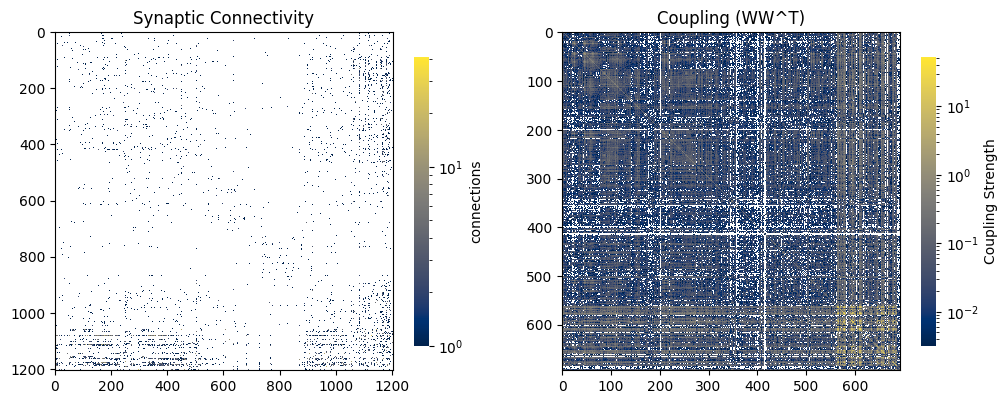

In [29]:
import matplotlib.colors as colors

# Load Structural Connectivity Matrix (J)
structural_matrix_path = os.path.join(data_dir, 'W_sorted_combined.csv')
Synaptic_Matrix = pd.read_csv(structural_matrix_path, index_col=0)

#structural_matrix_path = os.path.join(data_dir, 'connectome_connectivity', 'Connectivity_computed_20210114.pkl')

# 1. Prepare the data
# Convert to numpy array if it isn't already
W = Synaptic_Matrix.to_numpy()
np.fill_diagonal(W, 0)
#W = (W > 0).astype(float)

#input_counts = np.sum(W, axis=0)
#keep_mask = input_counts > 0
#W = W[keep_mask][:, keep_mask]

# Mask zeros (sparsity). This prevents LogNorm from throwing errors on 0 
# and allows us to set a specific background color for "no connection".
W_masked = np.ma.masked_where(W <= 0, W)

# 2. Plot using imshow (more efficient for matrices than heatmap)
# We use LogNorm to handle the scaling automatically.
fig5, ax5 = plt.subplots(1, 2, figsize=(12,5))

im = ax5[0].imshow(
    W_masked,
    cmap="cividis",
    norm=colors.LogNorm(vmin=W_masked.min(), vmax=W_masked.max()),
    aspect='equal',
    interpolation='nearest',  # Ensures crisp grid squares
    rasterized =True
)

# 3. Handle the "Sparse" areas (Zeros)
# Set the background color for masked values (zeros) to distinguish them from low values
ax5[0].set_facecolor('white') # or 'black', or 'lightgray'

# 4. Create the Colorbar
# The colorbar now automatically reads the Norm from the image 'im'
cb1 = fig5.colorbar(im, ax=ax5[0], shrink=0.75, label='connections')
cb1.outline.set_linewidth(0)

# 5. Final Formatting
ax5[0].set_title('Synaptic Connectivity')
# Remove ticks if desired, similar to the commented out lines in original code

Coupling = (W @ W.T)
N = W.shape[0]
Coupling = Coupling / np.trace(Coupling) * N
#np.fill_diagonal(Coupling, 0)

# Filter out nodes whose self-coupling (diagonal) is below a threshold                         
threshold = 1e-1 # adjust as needed                             
                                     
diag = np.diag(Coupling)           
keep_mask = diag >= threshold
n_removed = np.sum(~keep_mask)
print(f"Diagonal range:[{diag.min():.4g},{diag.max():.4g}]")
print(f"Removing {n_removed} / {len(diag)} nodes with diagonal < {threshold}")

# Apply mask to Coupling, W, and Synaptic_Matrix
Coupling = Coupling[np.ix_(keep_mask,keep_mask)]
W = W[keep_mask][:, keep_mask]
Synaptic_Matrix = Synaptic_Matrix.iloc[keep_mask, keep_mask]
N = Coupling.shape[0]
print(f"Remaining nodes: {N}")

#d = np.sqrt(np.diag(Coupling))
# 2. Normalize covariance to get correlation: C_ij / (std_i * std_j)
#np.outer(d, d) #creates the matrix of std_i * std_j
#Coupling = Coupling / np.outer(d, d)
# 3. (Optional) Ensure diagonal is exactly 1.0 to fix floating point errors
#np.fill_diagonal(Coupling, 1.0)

data_masked = np.ma.masked_where(Coupling <= 0, Coupling)

# 4. Plot using imshow
# We use LogNorm to visualize the wide dynamic range of the coupling matrix
im = ax5[1].imshow(
    data_masked,
    cmap="cividis",
    norm=colors.LogNorm(vmin=np.nanmin(data_masked), vmax=np.nanmax(data_masked)),
    aspect='equal',
    interpolation='nearest',
    rasterized=True
)

# 5. Styling
ax5[1].set_facecolor('white')
ax5[1].set_title('Coupling (WW^T)')

# 6. Add Colorbar
cb = fig5.colorbar(im, ax=ax5[1], shrink=0.75, label='Coupling Strength')
cb.outline.set_linewidth(0)

plt.show()





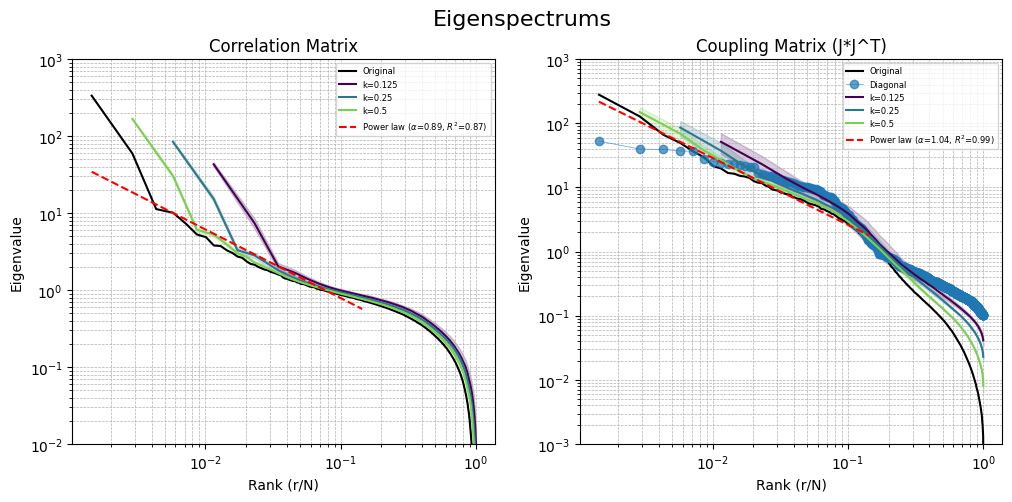

In [ ]:
g = 0.7
W0 = subsampling.generate_W_matrix(Coupling,g,seed=43)
#W = J.to_numpy() / (120.0 * N)
Correlation_Matrix = subsampling.compute_functional_connectivity(W0)

d = np.sqrt(np.diag(Correlation_Matrix))

# 2. Normalize covariance to get correlation: C_ij / (std_i * std_j)
#np.outer(d, d) #creates the matrix of std_i * std_j
Correlation_Matrix = Correlation_Matrix / np.outer(d, d)

# 3. (Optional) Ensure diagonal is exactly 1.0 to fix floating point errors
#np.fill_diagonal(Correlation_Matrix, 1.0)


evals = np.linalg.eigvalsh(Correlation_Matrix)
evals = np.sort(evals)[::-1]

fit_corr = subsampling.fit_power_law_eigenvalues(evals,100)

k_fractions = [0.125, 0.25, 0.5]
n_iter = 50

fig6, ax6 = plt.subplots(1, 2, figsize=(12, 5))
fig6.suptitle('Eigenspectrums', fontsize=16)

ranks_orig = (np.arange(len(evals)) + 1) / len(evals)
ax6[0].loglog(ranks_orig, evals, 'k-', linewidth=1.5, alpha=1.0, label='Original')
#ax6[0].loglog(ranks_orig, np.sort(np.diag(Correlation_Matrix))[::-1],'o-', linewidth=1, alpha =0.5, label='Diagonal')

colors = plt.cm.viridis(np.linspace(0, 0.8, len(k_fractions)))

for i, k_fraction in enumerate(k_fractions):
    mean_evals, std_evals, _ = subsampling.get_subsampled_eigenspectrum(Correlation_Matrix, k_fraction, n_iter)
    ranks_sub = (np.arange(len(mean_evals)) + 1) / len(mean_evals)
    ax6[0].loglog(ranks_sub, mean_evals, color=colors[i], linewidth=1.5, label='k={}'.format(k_fraction))
    ax6[0].fill_between(ranks_sub, mean_evals - std_evals, mean_evals + std_evals, color=colors[i], alpha=0.2)

ax6[0].loglog(fit_corr['data_x'], fit_corr['fitted_y'], 'r--', linewidth=1.5,
              label=r'Power law ($\alpha$={:.2f}, $R^2$={:.2f})'.format(fit_corr['exponent'], fit_corr['r_squared']))


ax6[0].set_xlabel('Rank (r/N)')
ax6[0].set_ylabel('Eigenvalue')
ax6[0].set_ylim([10**-2, 10**3])
ax6[0].legend(fontsize=6)
ax6[0].set_title('Correlation Matrix')
ax6[0].grid(True, which='both', linestyle='--', linewidth=0.5)



evals = np.linalg.eigvalsh(Coupling)
evals = np.sort(evals)[::-1]

fit_coupling = subsampling.fit_power_law_eigenvalues(evals,100)



ranks_orig = (np.arange(len(evals)) + 1) / len(evals)
ax6[1].loglog(ranks_orig, evals, 'k-', linewidth=1.5, alpha=1.0, label='Original')
ax6[1].loglog(ranks_orig, np.sort(np.diag(Coupling))[::-1],'o-', linewidth=0.5, alpha =0.7, label='Diagonal')


colors = plt.cm.viridis(np.linspace(0, 0.8, len(k_fractions)))

for i, k_fraction in enumerate(k_fractions):
    mean_evals, std_evals, _ = subsampling.get_subsampled_eigenspectrum(Coupling, k_fraction, n_iter)
    ranks_sub = (np.arange(len(mean_evals)) + 1) / len(mean_evals)
    ax6[1].loglog(ranks_sub, mean_evals, color=colors[i], linewidth=1.5, label='k={}'.format(k_fraction))
    ax6[1].fill_between(ranks_sub, mean_evals - std_evals, mean_evals + std_evals, color=colors[i], alpha=0.2)

ax6[1].loglog(fit_coupling['data_x'], fit_coupling['fitted_y'], 'r--', linewidth=1.5,
              label=r'Power law ($\alpha$={:.2f}, $R^2$={:.2f})'.format(fit_coupling['exponent'], fit_coupling['r_squared']))

ax6[1].set_xlabel('Rank (r/N)')
ax6[1].set_ylabel('Eigenvalue')
ax6[1].set_ylim([10**-3, 10**3])
ax6[1].legend(fontsize=6)
ax6[1].set_title('Coupling Matrix (J*J^T)')
ax6[1].grid(True, which='both', linestyle='--', linewidth=0.5)

#fig6.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()